In [2]:
import pandas as pd
from scipy.stats import spearmanr

import src
import src.load

In [3]:
%load_ext rpy2.ipython

In [4]:
%%R 

suppressMessages(library(tidyverse))
library(ggplot2)
library(ggeffects)
library(here)
library(ggpubr)

options(scipen = 999)


here() starts at /Users/lukas/git/ytpop
In addition: Warning messages:
1: package ‘ggplot2’ was built under R version 4.2.3 
2: package ‘tidyr’ was built under R version 4.2.3 
3: package ‘readr’ was built under R version 4.2.3 
4: package ‘dplyr’ was built under R version 4.2.3 
5: package ‘stringr’ was built under R version 4.2.3 


# Load Manifesto Data

In [5]:
manifesto_counts = src.load.manifestos()
manifesto_counts = (
    manifesto_counts.loc[~manifesto_counts.cmp_code.isin(["NA", "H"])]
    .groupby("party")
    .cmp_code.value_counts()
    .reset_index()
)
manifesto_counts["code"] = manifesto_counts["cmp_code"].str.split(".").str[0]
manifesto_counts = manifesto_counts.groupby(["party", "code"])["count"].sum().reset_index()

manifesto_counts = manifesto_counts.loc[manifesto_counts["code"] != "305"]

# Load YT Data

In [6]:
data = src.load.DataLoader()
table = (
    data.channels()
    .join(data.videos(filtered=True), "channel_id")
    .join(data.sentences(filtered=True), "video_id")
    .join(data.popbert(), "sentence_id")
    .join(data.manifesto_roberta(), "sentence_id")
    .select(["channel", "label", "elite", "pplcentr"])
)

base_df = table.to_pandas()
base_df["code"] = base_df["label"].str.split(" ").str[0]
base_df["populist"] = base_df.apply(
    lambda row: 1 if row["elite"] == 1 or row["pplcentr"] == 1 else 0, axis=1
)
base_df = base_df[base_df["code"] != "305"]

label_trans = base_df[["code", "label"]].copy().drop_duplicates()

In [7]:
yt_counts = base_df.groupby(["channel"]).code.value_counts().reset_index()
yt_counts["party"] = yt_counts.channel.replace(src.channel_to_party)

yt_counts_pop = base_df.groupby(["channel", "populist"]).code.value_counts().reset_index()
yt_counts_pop["party"] = yt_counts_pop.channel.replace(src.channel_to_party)
yt_counts_pop = (
    yt_counts_pop.sort_values(["party", "populist", "count"], ascending=[True, True, False])
    .groupby(["party", "populist"])
    .head(50)
)

# Do Analysis

In [8]:
df = pd.merge(
    yt_counts.rename({"count": "yt_count"}, axis=1),
    manifesto_counts.rename({"count": "manifesto_count"}, axis=1),
    how="inner",
    on=["party", "code"],
)


df_pop = pd.merge(
    yt_counts_pop.rename({"count": "yt_count"}, axis=1),
    manifesto_counts.rename({"count": "manifesto_count"}, axis=1),
    how="inner",
    on=["party", "code"],
)

In [9]:
df.groupby(["channel"])[["yt_count", "manifesto_count"]].corr(method="spearman")

yt_count  manifesto_count
channel                                           
AfD BT  yt_count         1.000000         0.788850
        manifesto_count  0.788850         1.000000
AfD TV  yt_count         1.000000         0.716860
        manifesto_count  0.716860         1.000000
CDU     yt_count         1.000000         0.686687
        manifesto_count  0.686687         1.000000
CSU     yt_count         1.000000         0.631688
        manifesto_count  0.631688         1.000000
FDP     yt_count         1.000000         0.726315
        manifesto_count  0.726315         1.000000
Greens  yt_count         1.000000         0.697124
        manifesto_count  0.697124         1.000000
Left    yt_count         1.000000         0.637958
        manifesto_count  0.637958         1.000000
SPD     yt_count         1.000000         0.746864
        manifesto_count  0.746864         1.000000

In [10]:
results = []
for (party, populist), group in df_pop.groupby(["channel", "populist"]):
    spearman, conf = spearmanr(group["yt_count"], group["manifesto_count"])
    results.append((party, populist, spearman))

plot_df = pd.DataFrame(results, columns=["party", "populist", "spearman"])

In [11]:
plot_df.head()

,party,populist,spearman
0,AfD BT,0,0.671790
1,AfD BT,1,0.750525
2,AfD TV,0,0.521053
3,AfD TV,1,0.681203
4,CDU,0,0.552277


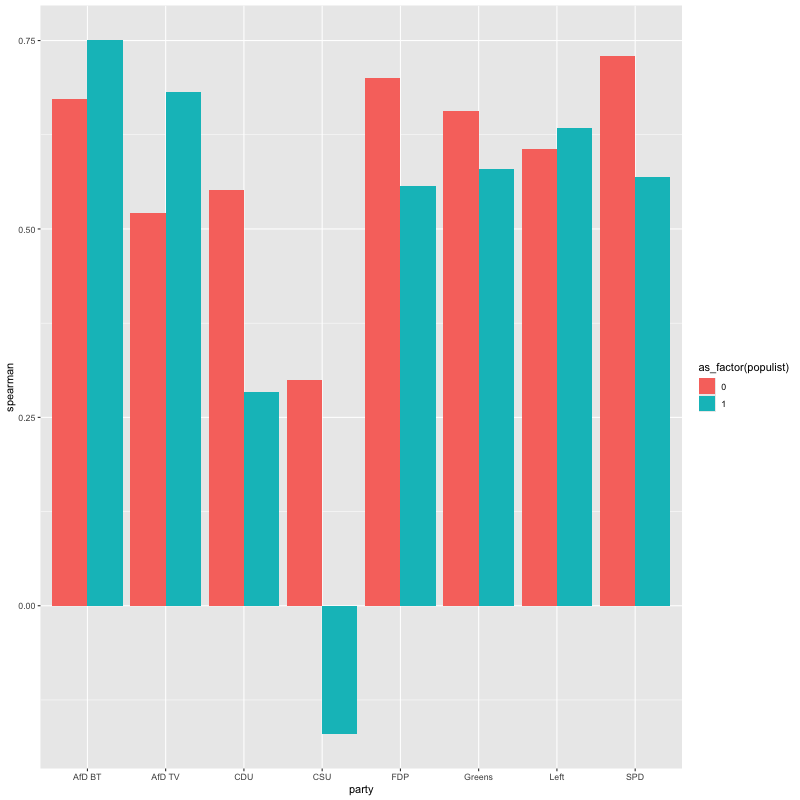

In [28]:
%%R -i plot_df -w 800 -h 800

ggplot(plot_df, aes(x=party, y=spearman, fill=as_factor(populist))) +
geom_bar(position=position_dodge(width=0.9), stat="identity")